# Детекция штрих-кодов классическими методами

Алгоритм повторяет схему из лекции: grayscale → Black Hat → направленный градиент → Gaussian Blur → Otsu → морфология → контуры → `boundingRect`.

Красным на изображениях обозначается ground truth, зелёным — предсказание. Основная метрика — IoU. Код самого детектора находится в `barcode_detector.py`, чтобы ноутбук и консольный запуск использовали одну реализацию.

## 1. Импорты и пути

Если зависимости ещё не установлены, выполните в терминале: `python -m pip install -r requirements.txt`.

In [8]:
from pathlib import Path
import importlib
import sys

import cv2
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data' / 'classicData').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import barcode_detector
importlib.reload(barcode_detector)

from barcode_detector import (
    DEFAULT_CONFIG,
    box_iou,
    build_feature_maps,
    detect_barcode,
    draw_detection,
    evaluate_dataset,
    summarize_results,
    DetectorConfig,
)

DATA_DIR = PROJECT_ROOT / 'data' / 'classicData'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'barcode_detection_notebook'
DATA_DIR

PosixPath('/Users/pozdnakov/PycharmProjects/CVStudy/data/classicData')

## 2. Чтение и проверка разметки

Несмотря на расширение `.tsv`, файл использует запятую в качестве разделителя. В фактической таблице присутствуют только имя изображения и координаты bbox.

In [9]:
annotations = pd.read_csv(DATA_DIR / 'annotations.tsv', sep=',')

print('Строк:', len(annotations))
print('Уникальных изображений:', annotations['filename'].nunique())
print('Пропусков:', int(annotations.isna().sum().sum()))
display(annotations.head())
display(annotations[['x_from', 'y_from', 'width', 'height']].describe().round(2))

Строк: 76
Уникальных изображений: 76
Пропусков: 0


,filename,x_from,y_from,width,height
0,images/0b56af7e-386c-410a-8f46-74350f755d77--r...,216,474,409,308
1,images/6e042372-20ec-4a26-8340-3653cf0c681d--r...,23,849,230,125
2,images/788fb7f3-e813-4754-874f-3cc6eb19113d--r...,322,632,344,145
3,images/d05d50c0-0c19-4ca4-88ff-6f7058318a7f--r...,516,694,325,156
4,images/93cda132-8b66-476a-a112-8acf47658fee--r...,200,474,531,292


,x_from,y_from,width,height
count,76.00,76.00,76.00,76.00
mean,281.41,616.54,420.49,224.41
std,114.60,208.38,91.77,77.18
min,23.00,142.00,226.00,108.00
25%,198.25,495.50,371.75,161.75
50%,270.50,606.50,430.00,210.00
75%,343.25,786.50,466.25,277.75
max,595.00,1170.00,682.00,471.00


## 3. Параметры детектора

Все изображения приводятся к ширине 1000 пикселей. После Closing, erosion и dilation находятся внешние контуры. Из них выбирается кандидат с максимальным отношением градиента по X к сумме градиентов по X и Y. Параметры можно менять через собственный экземпляр `DetectorConfig`.

In [10]:
config = DEFAULT_CONFIG
config

DetectorConfig(working_width=1000, blackhat_kernel=(15, 5), blur_kernel=(9, 9), morphology_kernel=(21, 5), erode_iterations=2, dilate_iterations=4, min_area_fraction=0.003, max_area_fraction=0.4, min_aspect_ratio=0.25, max_aspect_ratio=8.0, min_width=40, min_height=15)

## 4. Промежуточные этапы на одном изображении

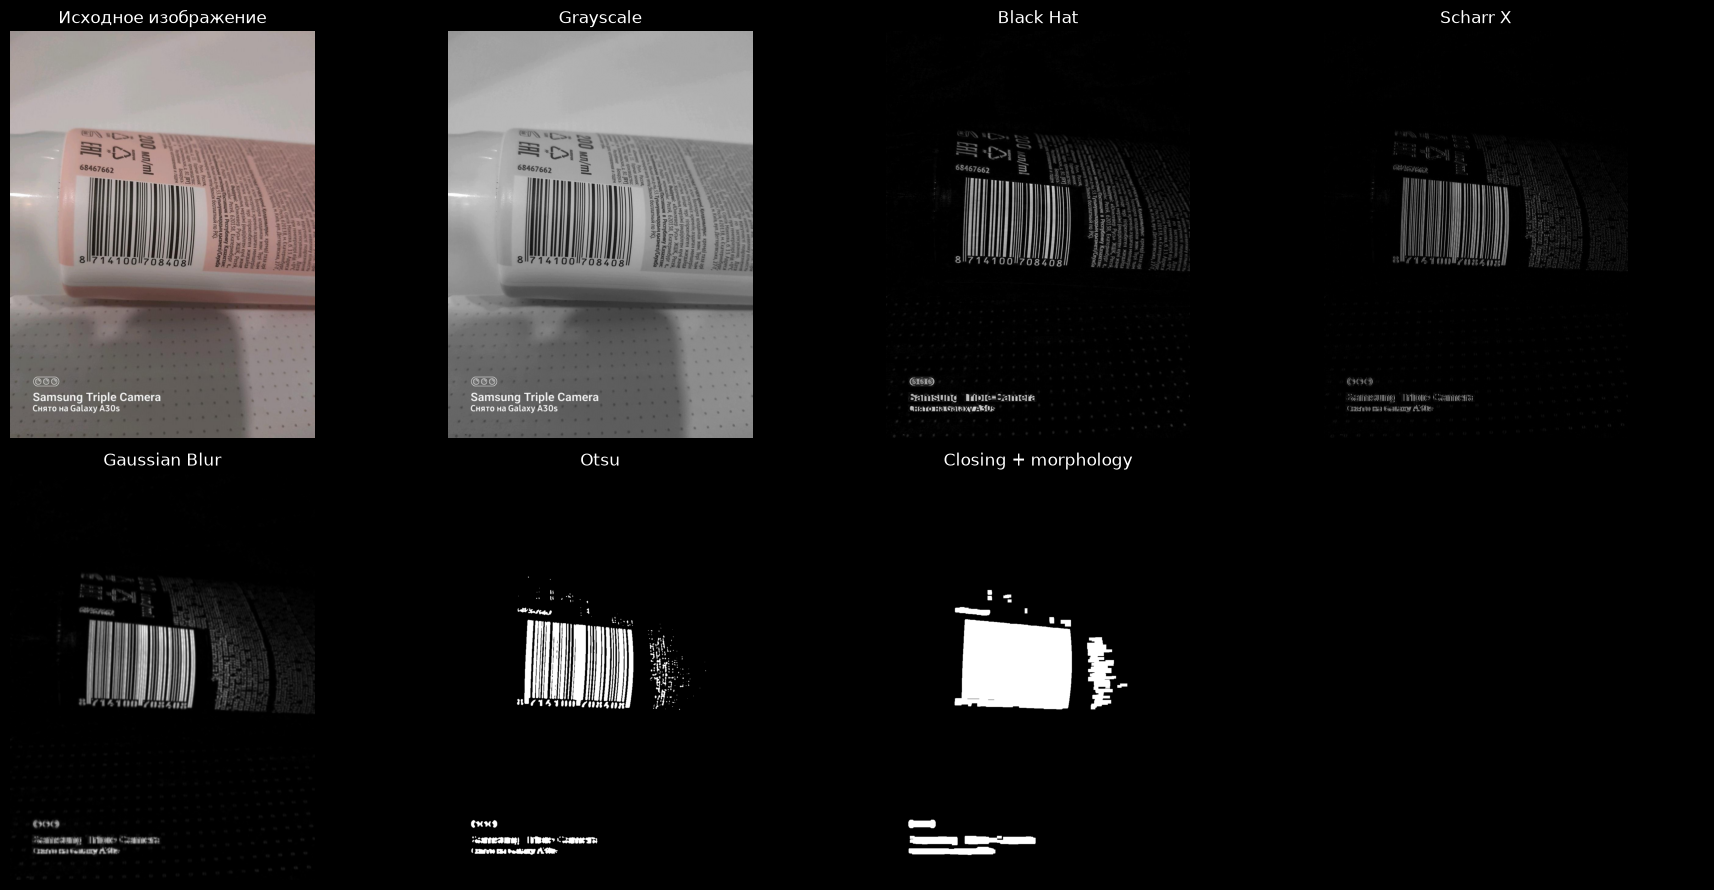

In [15]:
sample_index = 0
row = annotations.iloc[sample_index]
image_path = DATA_DIR / row['filename']
image = cv2.imread(str(image_path))
assert image is not None, f'Не удалось прочитать {image_path}'

ground_truth = tuple(int(row[name]) for name in ['x_from', 'y_from', 'width', 'height'])
maps = build_feature_maps(image, config)

stages = [
    ('Исходное изображение', cv2.cvtColor(maps['working'], cv2.COLOR_BGR2RGB), None),
    ('Grayscale', maps['gray'], 'gray'),
    ('Black Hat', maps['blackhat'], 'gray'),
    ('Scharr X', maps['gradient'], 'gray'),
    ('Gaussian Blur', maps['blurred'], 'gray'),
    ('Otsu', maps['binary'], 'gray'),
    ('Closing + morphology', maps['morphology_mask'], 'gray'),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for axis, (title, stage, cmap) in zip(axes.flat, stages):
    axis.imshow(stage, cmap=cmap)
    axis.set_title(title)
    axis.axis('off')
for axis in axes.flat[len(stages):]:
    axis.axis('off')
plt.tight_layout()

## 5. Детекция и IoU одного изображения

Кандидаты формируются через `findContours(..., RETR_EXTERNAL, ...)`. Для каждого используется `boundingRect`. После фильтрации по размеру выбирается область, в которой градиент по X сильнее градиента по Y — это характерно для вертикальных полос штрих-кода.

Ground truth: (216, 474, 409, 308)
Prediction:   (226, 477, 385, 296)
IoU:          0.9046
Кандидатов:   3


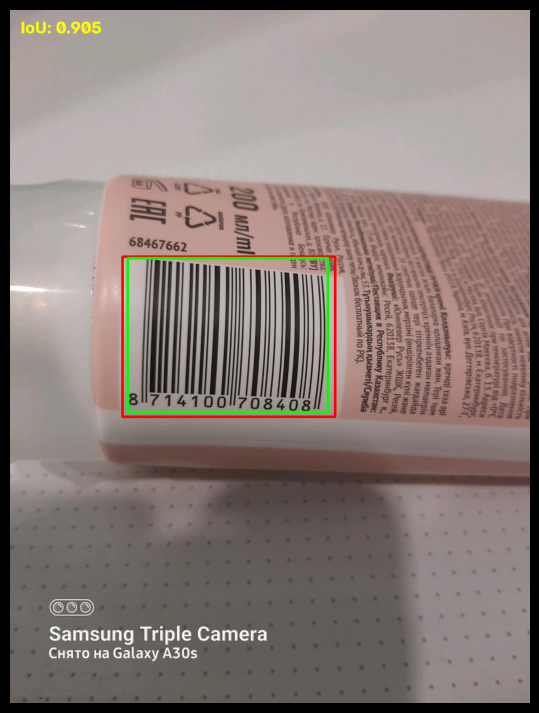

In [16]:
prediction, debug = detect_barcode(image, config, return_debug=True)
sample_iou = box_iou(prediction, ground_truth) if prediction is not None else 0.0
rendered = draw_detection(image, prediction, ground_truth, sample_iou)

print('Ground truth:', ground_truth)
print('Prediction:  ', prediction)
print(f'IoU:          {sample_iou:.4f}')
print('Кандидатов:  ', len(debug['candidates']))

plt.figure(figsize=(9, 9))
plt.imshow(cv2.cvtColor(rendered, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

## 6. Запуск на всём датасете

Результаты сохраняются в `outputs/barcode_detection_notebook`: `predictions.csv`, `metrics.json` и изображения с разметкой.

In [17]:
results = evaluate_dataset(
    DATA_DIR,
    config=config,
    output_dir=OUTPUT_DIR,
    save_images=True,
)
metrics = summarize_results(results)
display(pd.Series(metrics, name='value').to_frame())
display(results.sort_values('iou').head(10))

,value
images,76.000000
mean_iou,0.872692
median_iou,0.916051
min_iou,0.116330
images_iou_at_least_0_8,68.000000
fraction_iou_at_least_0_8,0.894737


,filename,x_from,y_from,width,height,score,iou
14,images/468376b5-89e0-4658-9471-c03f2cdf9cfc--r...,380,901,96,138,0.859555,0.116330
17,images/9185f86c-3aee-43f6-a758-febdbd9281c5--r...,472,182,118,259,0.826009,0.139187
72,images/b5c905af-95d7-4a15-abac-3ec01e01ff51--r...,207,461,159,272,0.846821,0.292758
33,images/c9ffc301-76cc-4713-8c37-ca3c90bb89c5--r...,196,733,221,173,0.834469,0.470313
59,images/f20f263b-3a99-451b-8f60-90a440a23b60--r...,0,518,786,154,0.706323,0.549940
13,images/77252d88-2d4f-4741-a507-1aee82b4ca53--r...,370,825,330,162,0.823260,0.639731
54,images/818f55e6-0cf3-4df7-a3bb-b9d063d8e153--r...,524,421,402,199,0.816001,0.772112
28,images/758e22fa-7bc0-4d31-8c2b-19dd8173d2dc--r...,300,544,403,220,0.796103,0.788862
64,images/aeaf9f35-5865-463c-8ed0-6c01fcd5d4bc--r...,369,559,371,169,0.814934,0.803827
9,images/6f8eeeda-3403-4c81-b37d-f9bbfada0e65--r...,376,356,512,353,0.826824,0.822234


## 7. Анализ худших результатов

Такая визуализация полезна при настройке морфологических ядер. Красная рамка — ground truth, зелёная — результат детектора.

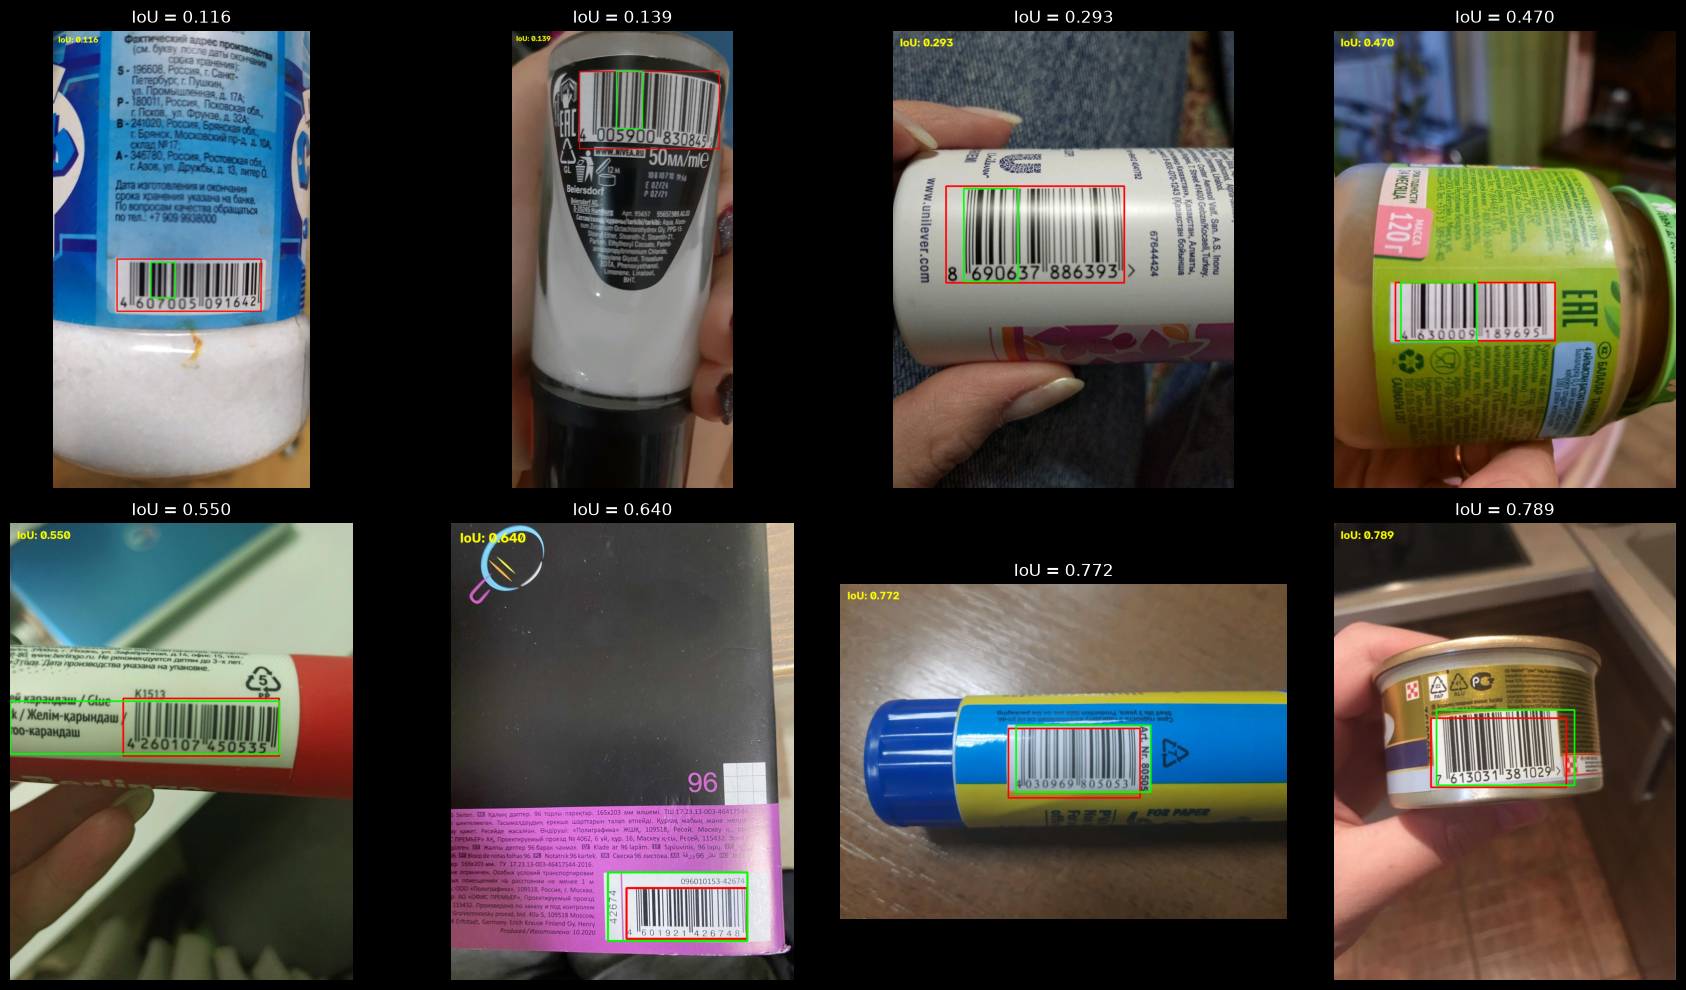

In [18]:
worst = results.nsmallest(8, 'iou')
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

for axis, result in zip(axes.flat, worst.itertuples(index=False)):
    source_row = annotations.loc[annotations['filename'] == result.filename].iloc[0]
    source = cv2.imread(str(DATA_DIR / result.filename))
    gt = tuple(int(source_row[name]) for name in ['x_from', 'y_from', 'width', 'height'])
    pred = None if result.x_from < 0 else (result.x_from, result.y_from, result.width, result.height)
    shown = draw_detection(source, pred, gt, result.iou)
    axis.imshow(cv2.cvtColor(shown, cv2.COLOR_BGR2RGB))
    axis.set_title(f'IoU = {result.iou:.3f}')
    axis.axis('off')

plt.tight_layout()